## 1. Imports

In [75]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
 
sns.set_style("whitegrid")
%matplotlib inline

## 2. Load Data

In [76]:
training = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
 
training['train_test'] = 1
test['train_test'] = 0
test['Survived'] = np.nan
all_data = pd.concat([training, test]).reset_index(drop=True)
 
print("Training shape:", training.shape)
print("Test shape:", test.shape)
all_data.columns

Training shape: (891, 13)
Test shape: (418, 13)


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'train_test'],
      dtype='object')

## 3. Exploratory Data Analysis

In [77]:
# quick look at data types & null counts 
training.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
 12  train_test   891 non-null    int64  
dtypes: float64(2), int64(6), object(5)
memory usage: 90.6+ KB


In [78]:
# to better understand the numeric data, .describe() method gives an understanding of the central tendencies of the data 
training.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,train_test
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.0
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,1.0
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.0
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,1.0
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.0
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.0
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.0
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.0


In [79]:
training.describe().columns

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
       'train_test'],
      dtype='object')

In [80]:
# look at numeric and categorical values separately 
df_num = training[['Age','SibSp','Parch','Fare']]
df_cat = training[['Survived','Pclass','Sex','Ticket','Cabin','Embarked']]

### Visualization

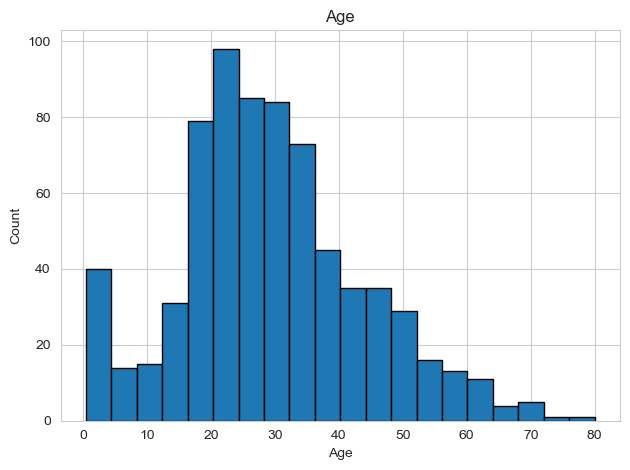

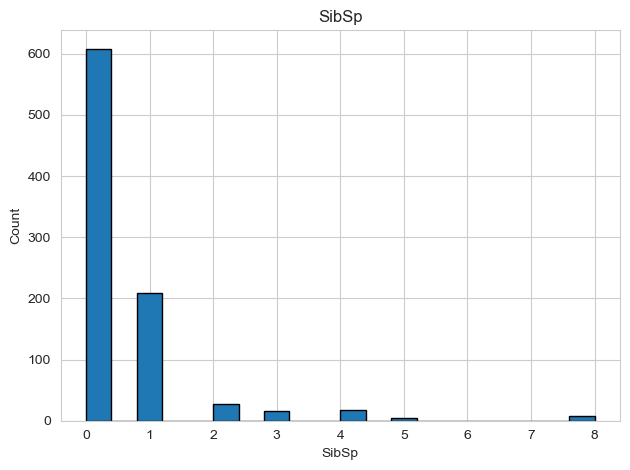

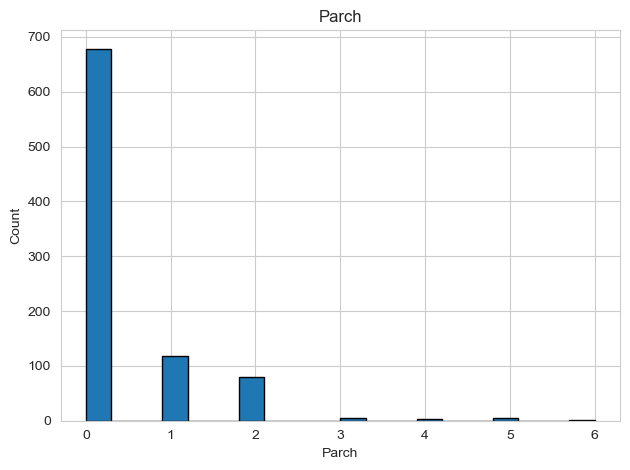

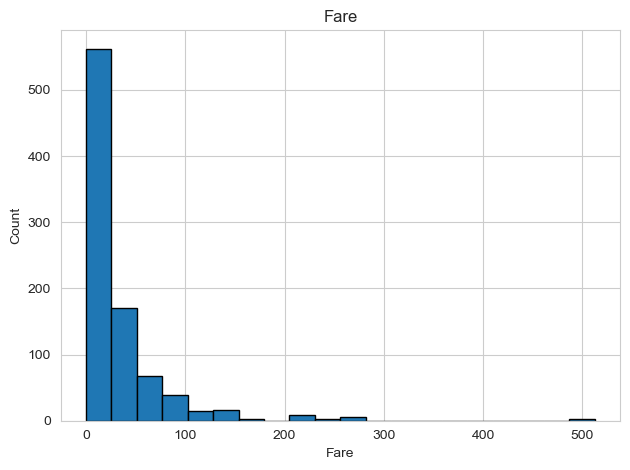

In [81]:
#distributions for all numeric variables 
for col in df_num.columns:
    plt.hist(df_num[col], bins=20, edgecolor='black')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

            Age     SibSp     Parch      Fare
Age    1.000000 -0.308247 -0.189119  0.096067
SibSp -0.308247  1.000000  0.414838  0.159651
Parch -0.189119  0.414838  1.000000  0.216225
Fare   0.096067  0.159651  0.216225  1.000000


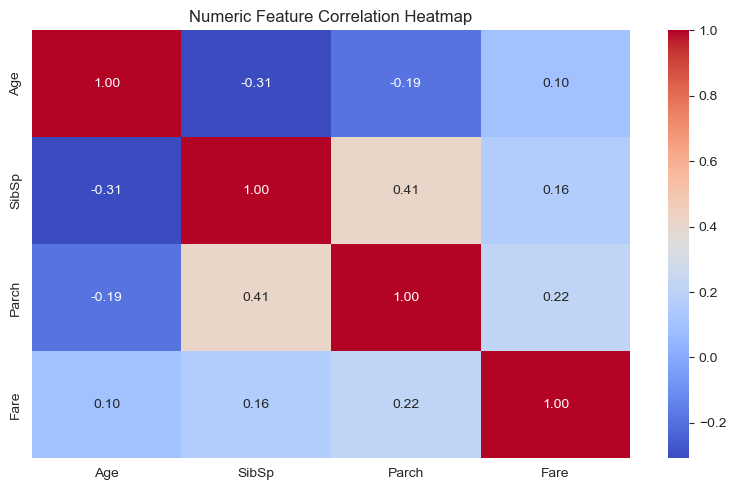

In [82]:
# numeric correlations
print(df_num.corr())
plt.figure(figsize=(8, 5))
sns.heatmap(df_num.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Numeric Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Surival Visualizations

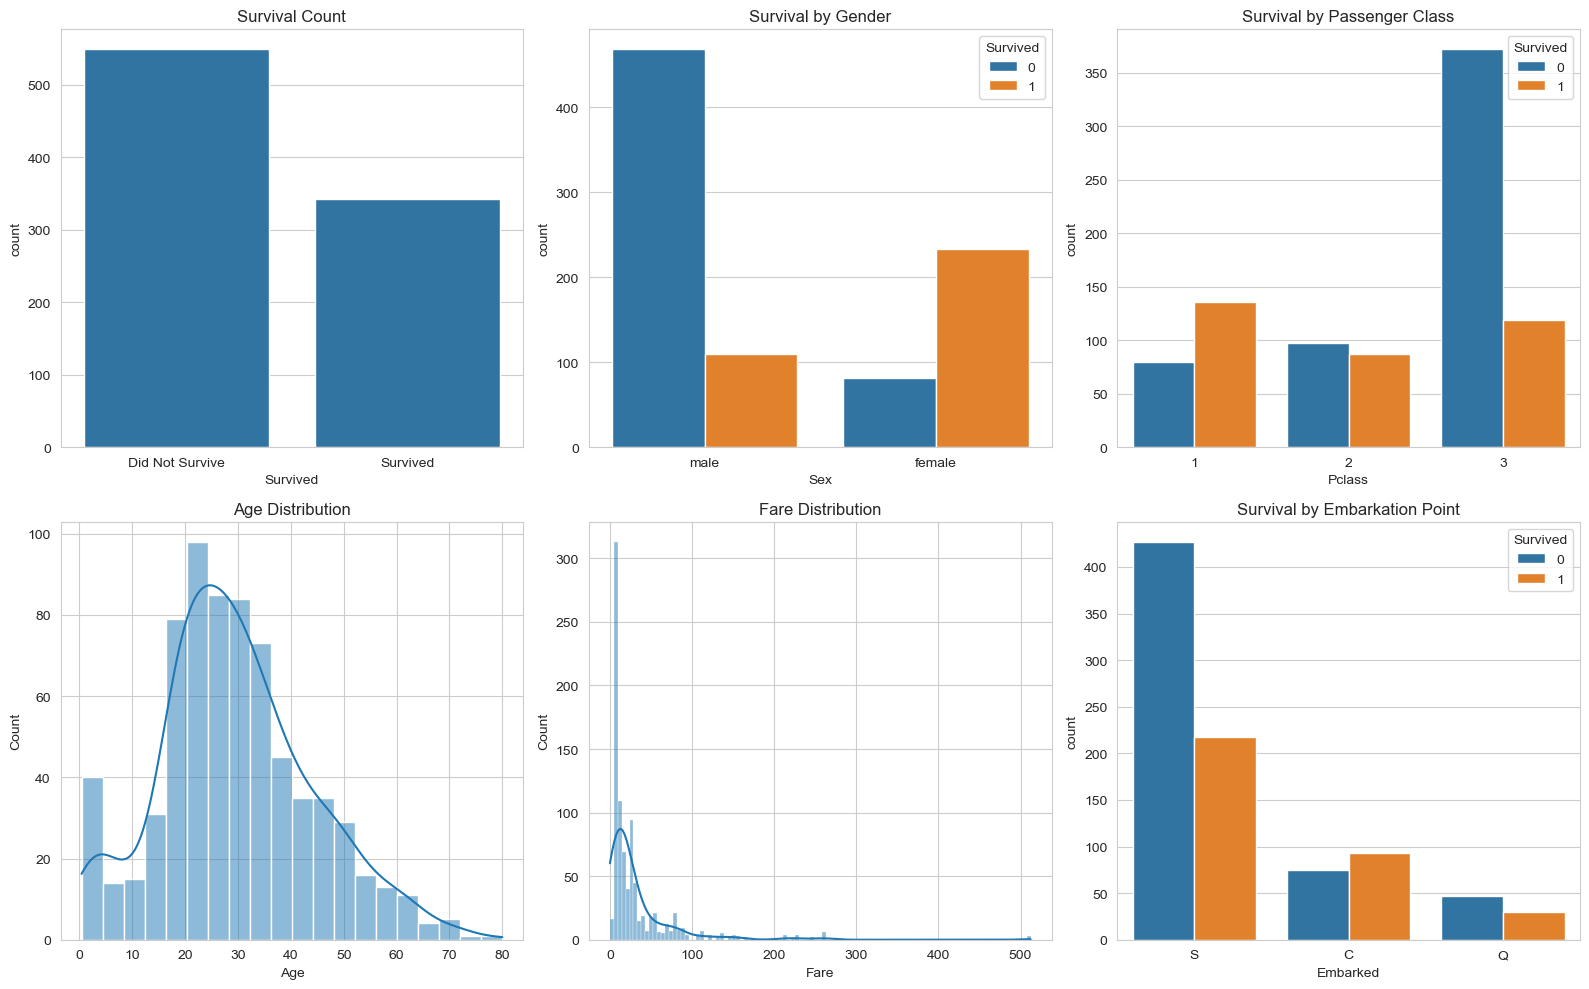

In [83]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
 
# Survival count
sns.countplot(x="Survived", data=training, ax=axes[0, 0])
axes[0, 0].set_title("Survival Count")
axes[0, 0].set_xticklabels(['Did Not Survive', 'Survived'])
 
# Survival by gender
sns.countplot(x="Sex", hue="Survived", data=training, ax=axes[0, 1])
axes[0, 1].set_title("Survival by Gender")
 
# Survival by class
sns.countplot(x="Pclass", hue="Survived", data=training, ax=axes[0, 2])
axes[0, 2].set_title("Survival by Passenger Class")
 
# Age distribution
sns.histplot(training["Age"].dropna(), kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Age Distribution")
 
# Fare distribution
sns.histplot(training["Fare"], kde=True, ax=axes[1, 1])
axes[1, 1].set_title("Fare Distribution")
 
# Survival by embarkation point
sns.countplot(x="Embarked", hue="Survived", data=training, ax=axes[1, 2])
axes[1, 2].set_title("Survival by Embarkation Point")
 
plt.tight_layout()
plt.show()

### Pivot Tables

In [84]:
# compare survival rate across Age, SibSp, Parch, and Fare 
pd.pivot_table(training, index = 'Survived', values = ['Age','SibSp','Parch','Fare'])

,Age,Fare,Parch,SibSp
Survived,,,,
0,30.626179,22.117887,0.329690,0.553734
1,28.343690,48.395408,0.464912,0.473684


In [85]:
# Comparing survival and each of these categorical variables 
print("Survival by Pclass:")
print(pd.pivot_table(training, index='Survived', columns='Pclass', values='Ticket', aggfunc='count'))
print()
print("Survival by Sex:")
print(pd.pivot_table(training, index='Survived', columns='Sex', values='Ticket', aggfunc='count'))
print()
print("Survival by Embarked:")
print(pd.pivot_table(training, index='Survived', columns='Embarked', values='Ticket', aggfunc='count'))

Survival by Pclass:
Pclass      1   2    3
Survived              
0          80  97  372
1         136  87  119

Survival by Sex:
Sex       female  male
Survived              
0             81   468
1            233   109

Survival by Embarked:
Embarked   C   Q    S
Survived             
0         75  47  427
1         93  30  217


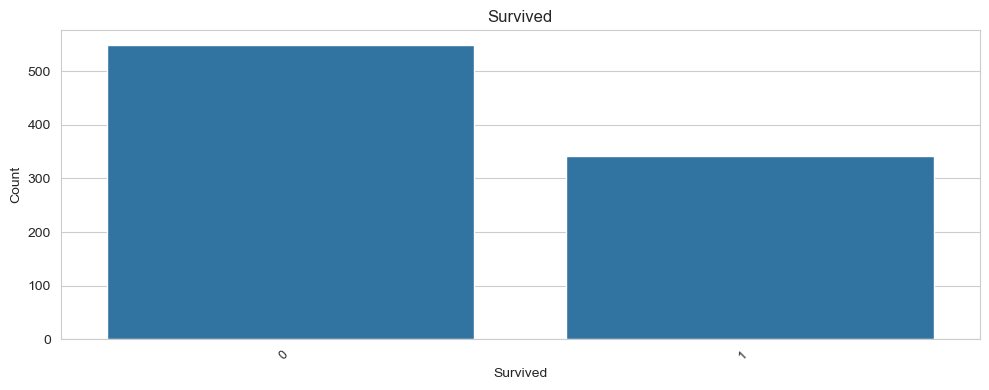

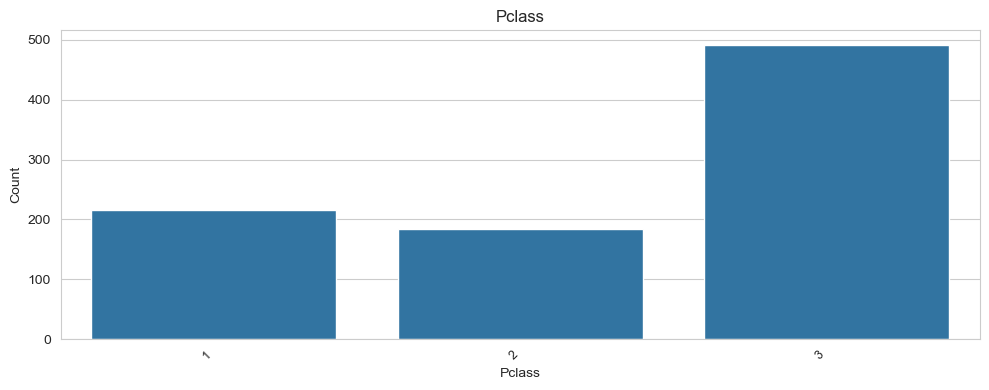

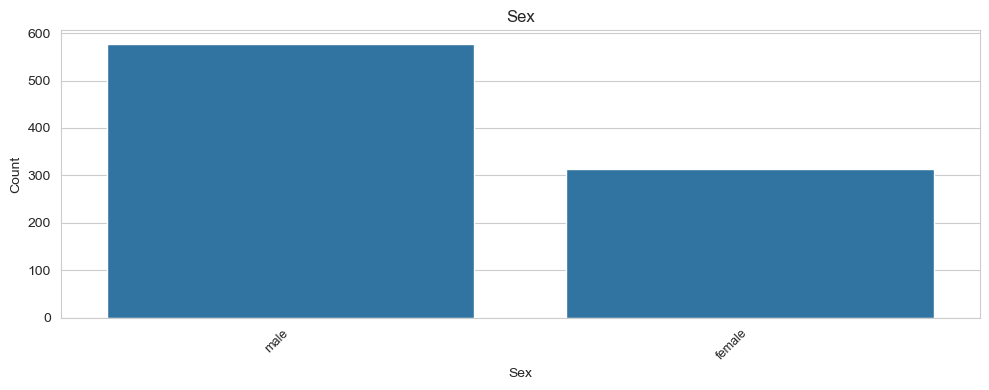

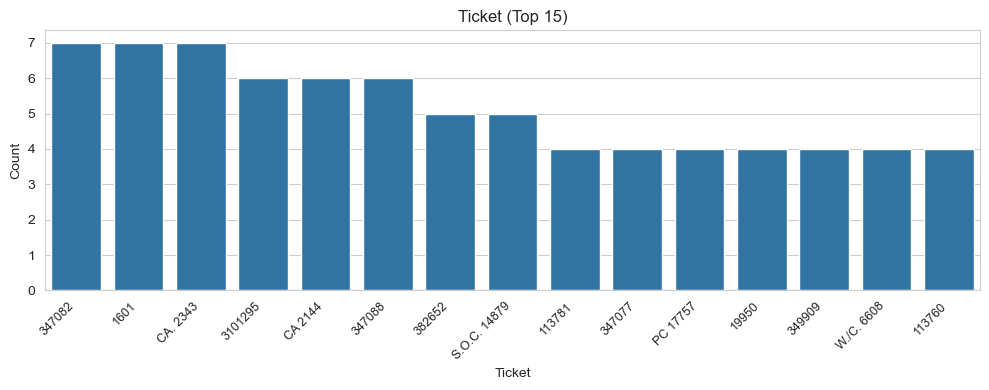

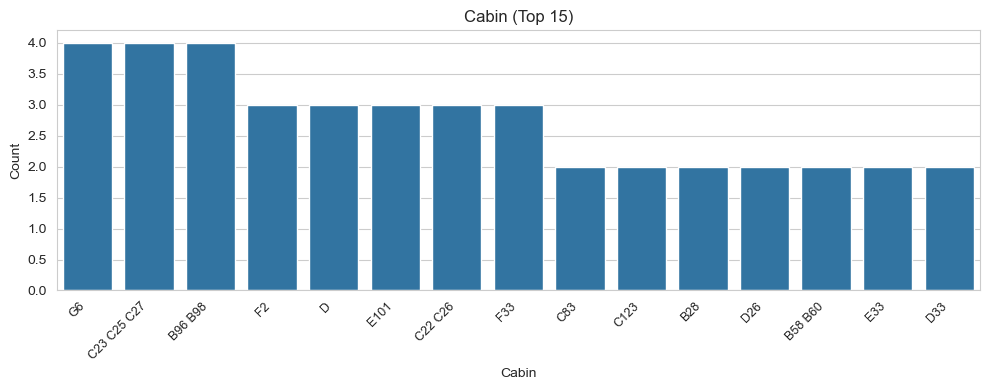

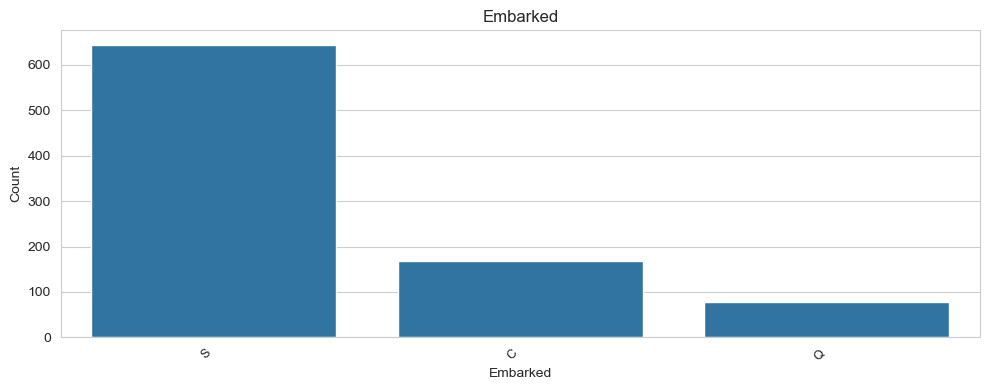

In [108]:
# categorical value counts
for col in df_cat.columns:
    counts = df_cat[col].value_counts()
    
    # Cap high-cardinality columns to top 15 for readability
    if len(counts) > 15:
        counts = counts.head(15)
        title = f"{col} (Top 15)"
    else:
        title = col
    
    plt.figure(figsize=(10, 4))
    sns.barplot(x=counts.index, y=counts.values)
    plt.title(title)
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## 4. Feature Engineering

In [87]:
# Cabin features

all_data['cabin_multiple'] = all_data.Cabin.apply(lambda x: 0 if pd.isna(x) else len(x.split(' ')))
all_data['cabin_adv'] = all_data.Cabin.apply(lambda x: str(x)[0])

print("Cabin multiple value counts:")
print(all_data['cabin_multiple'].value_counts())

Cabin multiple value counts:
cabin_multiple
0    1014
1     254
2      26
3      10
4       5
Name: count, dtype: int64


In [88]:
# Use training rows from all_data so engineered features are available
train_view = all_data[all_data['train_test'] == 1].copy()
pd.pivot_table(train_view, index='Survived', columns='cabin_multiple', values='Ticket', aggfunc='count')

cabin_multiple,0,1,2,3,4
Survived,,,,,
0.0,481.0,58.0,7.0,3.0,NaN
1.0,206.0,122.0,9.0,3.0,2.0


In [89]:
# ticket features

all_data['numeric_ticket'] = all_data.Ticket.apply(lambda x: 1 if x.isnumeric() else 0)
all_data['ticket_letters'] = all_data.Ticket.apply(
    lambda x: ''.join(x.split(' ')[:-1]).replace('.', '').replace('/', '').lower()
    if len(x.split(' ')[:-1]) > 0 else 0
)

print("Cabin deck survival breakdown:")
print(pd.pivot_table(train_view, index='Survived', columns='cabin_adv', values='Name', aggfunc='count'))

print("Numeric vs Non-numeric tickets:")
print(all_data['numeric_ticket'].value_counts())

Cabin deck survival breakdown:
cabin_adv    A     B     C     D     E    F    G    T      n
Survived                                                    
0.0        8.0  12.0  24.0   8.0   8.0  5.0  2.0  1.0  481.0
1.0        7.0  35.0  35.0  25.0  24.0  8.0  2.0  NaN  206.0
Numeric vs Non-numeric tickets:
numeric_ticket
1    957
0    352
Name: count, dtype: int64


In [90]:
# name_title feature

all_data['name_title'] = all_data.Name.apply(lambda x: x.split(',')[1].split('.')[0].strip())

# Refresh train_view to include all engineered features so far
train_view = all_data[all_data['train_test'] == 1].copy()
print("Title value counts:")
print(all_data['name_title'].value_counts())

Title value counts:
name_title
Mr              757
Miss            260
Mrs             197
Master           61
Rev               8
Dr                8
Col               4
Major             2
Mlle              2
Ms                2
Mme               1
Don               1
Sir               1
Lady              1
Capt              1
the Countess      1
Jonkheer          1
Dona              1
Name: count, dtype: int64


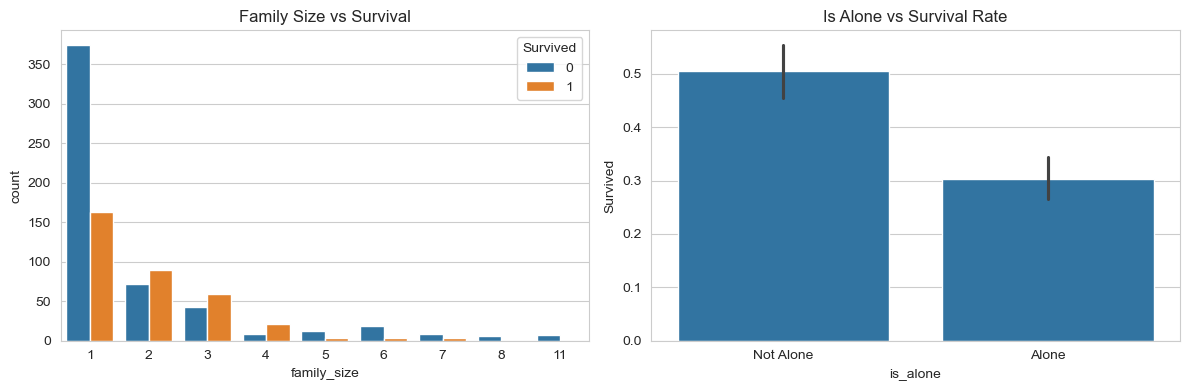

In [91]:
# family_size and is_alone

# New features: total family size and whether a passenger traveled alone
# Both are known to correlate with survival (solo travelers fared worse)
all_data['family_size'] = all_data['SibSp'] + all_data['Parch'] + 1
all_data['is_alone'] = (all_data['family_size'] == 1).astype(int)

# Visualize on training set
train_fe = all_data[all_data['train_test'] == 1].copy()
train_fe['Survived'] = training['Survived'].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x="family_size", hue="Survived", data=train_fe, ax=axes[0])
axes[0].set_title("Family Size vs Survival")

sns.barplot(x="is_alone", y="Survived", data=train_fe, ax=axes[1])
axes[1].set_title("Is Alone vs Survival Rate")
axes[1].set_xticklabels(['Not Alone', 'Alone'])

plt.tight_layout()
plt.show()


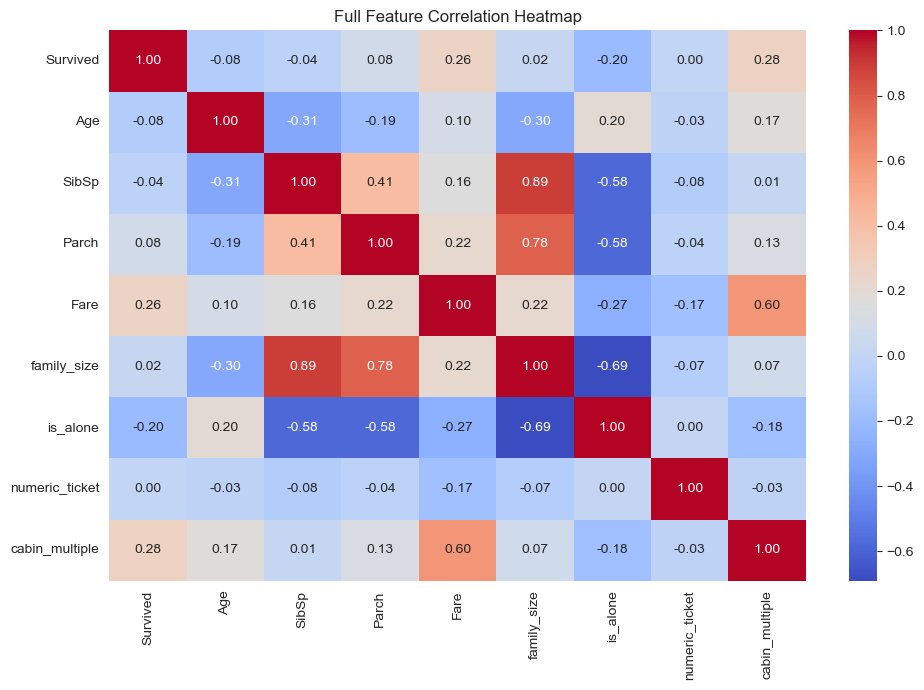

In [92]:
# correlation heatmap (post feature engineering)

train_numeric = train_fe[['Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'family_size', 'is_alone', 'numeric_ticket', 'cabin_multiple']]
plt.figure(figsize=(10, 7))
sns.heatmap(train_numeric.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Full Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 5. Data Preprocessing

In [93]:
# Create all engineered features on combined data (already done above)
# Impute nulls using training medians (avoids data leakage)
all_data['Age'] = all_data['Age'].fillna(training['Age'].median())
all_data['Fare'] = all_data['Fare'].fillna(training['Fare'].median())
 
# Drop the 2 null Embarked rows (training only)
all_data.dropna(subset=['Embarked'], inplace=True)
 
# Log-normalize fare to reduce right skew
all_data['norm_fare'] = np.log(all_data['Fare'] + 1)
 
# Cast Pclass to string for one-hot encoding
all_data['Pclass'] = all_data['Pclass'].astype(str)
 
# One-hot encode all categorical features
feature_cols = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'norm_fare',
    'Embarked', 'cabin_adv', 'cabin_multiple', 'numeric_ticket',
    'name_title', 'family_size', 'is_alone', 'train_test'
]
all_dummies = pd.get_dummies(all_data[feature_cols])

In [94]:
# Split back to train/test
X_train = all_dummies[all_dummies['train_test'] == 1].drop(['train_test'], axis=1)
X_test = all_dummies[all_dummies['train_test'] == 0].drop(['train_test'], axis=1)
y_train = all_data[all_data['train_test'] == 1]['Survived']
 
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
 
# Scale continuous features
scale = StandardScaler()
all_dummies_scaled = all_dummies.copy()
all_dummies_scaled[['Age', 'SibSp', 'Parch', 'norm_fare', 'family_size']] = scale.fit_transform(
    all_dummies_scaled[['Age', 'SibSp', 'Parch', 'norm_fare', 'family_size']]
)
 
X_train_scaled = all_dummies_scaled[all_dummies_scaled['train_test'] == 1].drop(['train_test'], axis=1)
X_test_scaled = all_dummies_scaled[all_dummies_scaled['train_test'] == 0].drop(['train_test'], axis=1)
y_train = all_data[all_data['train_test'] == 1]['Survived']

X_train shape: (889, 43)
X_test shape: (418, 43)


## 6. Baseline Model Comparison (5-Fold CV)

In [95]:
# Before tuning, benchmark every model at default params.
# This shows interviewers you understand the modeling pipeline end-to-end.
 
def run_baseline(model, name, X, y, cv=5):
    scores = cross_val_score(model, X, y, cv=cv)
    print(f"{name:30s} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")
    return scores.mean()
 
print(f"{'Model':30s} | Mean CV Accuracy | Std")
print("-" * 60)
 
baseline_results = {}
baseline_results['Naive Bayes']         = run_baseline(GaussianNB(), 'Naive Bayes', X_train_scaled, y_train)
baseline_results['Logistic Regression'] = run_baseline(LogisticRegression(max_iter=2000), 'Logistic Regression', X_train_scaled, y_train)
baseline_results['Decision Tree']       = run_baseline(tree.DecisionTreeClassifier(random_state=1), 'Decision Tree', X_train_scaled, y_train)
baseline_results['KNN']                 = run_baseline(KNeighborsClassifier(), 'KNN', X_train_scaled, y_train)
baseline_results['Random Forest']       = run_baseline(RandomForestClassifier(random_state=1), 'Random Forest', X_train_scaled, y_train)
baseline_results['SVC']                 = run_baseline(SVC(probability=True), 'SVC', X_train_scaled, y_train)
baseline_results['XGBoost']             = run_baseline(XGBClassifier(random_state=1, verbosity=0), 'XGBoost', X_train_scaled, y_train)

Model                          | Mean CV Accuracy | Std
------------------------------------------------------------
Naive Bayes                    | Mean: 0.7244 | Std: 0.0347
Logistic Regression            | Mean: 0.8178 | Std: 0.0200
Decision Tree                  | Mean: 0.7795 | Std: 0.0371
KNN                            | Mean: 0.8055 | Std: 0.0352
Random Forest                  | Mean: 0.8065 | Std: 0.0437
SVC                            | Mean: 0.8313 | Std: 0.0220
XGBoost                        | Mean: 0.8189 | Std: 0.0318


In [96]:
# Voting Classifier baseline
gnb = GaussianNB()
lr_base = LogisticRegression(max_iter=2000)
knn_base = KNeighborsClassifier()
rf_base = RandomForestClassifier(random_state=1)
svc_base = SVC(probability=True)
xgb_base = XGBClassifier(random_state=1, verbosity=0)
 
voting_base = VotingClassifier(
    estimators=[('lr', lr_base), ('knn', knn_base), ('rf', rf_base),
                ('gnb', gnb), ('svc', svc_base), ('xgb', xgb_base)],
    voting='soft'
)
baseline_results['Soft Voting (All)'] = run_baseline(voting_base, 'Soft Voting (All)', X_train_scaled, y_train)

Soft Voting (All)              | Mean: 0.8201 | Std: 0.0171


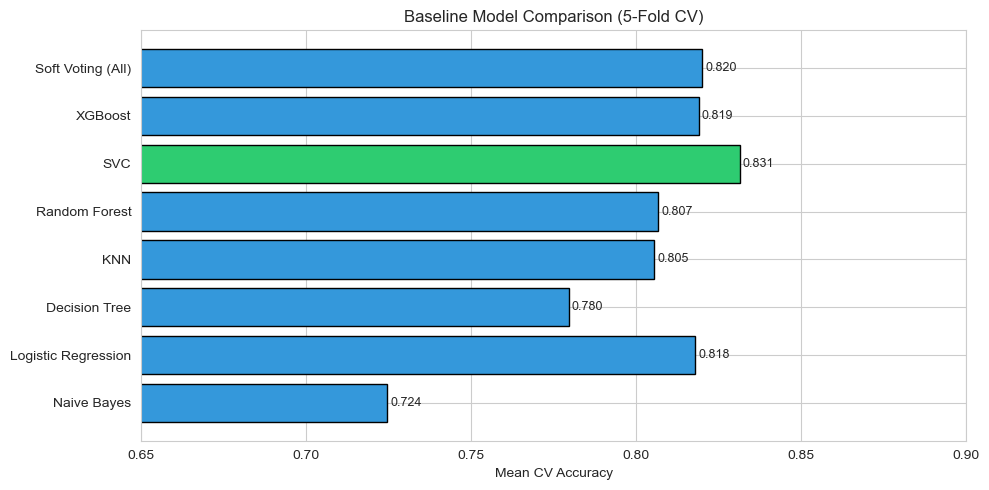

In [97]:
# Plot baseline results
plt.figure(figsize=(10, 5))
models = list(baseline_results.keys())
scores = list(baseline_results.values())
colors = ['#2ecc71' if s == max(scores) else '#3498db' for s in scores]
bars = plt.barh(models, scores, color=colors, edgecolor='black')
plt.xlabel("Mean CV Accuracy")
plt.title("Baseline Model Comparison (5-Fold CV)")
plt.xlim(0.65, 0.90)
for bar, score in zip(bars, scores):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{score:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()


## 7. Hyperparameter Tuning

In [98]:
 def clf_performance(classifier, model_name):
    print(f"\n{model_name}")
    print(f"  Best Score:      {classifier.best_score_:.4f}")
    print(f"  Best Parameters: {classifier.best_params_}")

In [99]:
# 1. Logistic Regression
lr = LogisticRegression()
param_grid = {
    'max_iter': [2000],
    'penalty': ['l1', 'l2'],
    'C': np.logspace(-4, 4, 20),
    'solver': ['liblinear']
}
clf_lr = GridSearchCV(lr, param_grid=param_grid, cv=5, n_jobs=-1)
best_clf_lr = clf_lr.fit(X_train_scaled, y_train)
clf_performance(best_clf_lr, 'Logistic Regression')


Logistic Regression
  Best Score:      0.8257
  Best Parameters: {'C': np.float64(1.623776739188721), 'max_iter': 2000, 'penalty': 'l1', 'solver': 'liblinear'}


In [100]:
# 2. KNN
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'p': [1, 2]
}
clf_knn = GridSearchCV(knn, param_grid=param_grid, cv=5, n_jobs=-1)
best_clf_knn = clf_knn.fit(X_train_scaled, y_train)
clf_performance(best_clf_knn, 'KNN')


KNN
  Best Score:      0.8257
  Best Parameters: {'algorithm': 'ball_tree', 'n_neighbors': 7, 'p': 2, 'weights': 'uniform'}


In [101]:
# 3. SVC
svc = SVC(probability=True)
param_grid = [
    {'kernel': ['rbf'], 'gamma': [.1, .5, 1, 2, 5, 10], 'C': [.1, 1, 10, 100, 1000]},
    {'kernel': ['linear'], 'C': [.1, 1, 10, 100, 1000]},
    {'kernel': ['poly'], 'degree': [2, 3, 4, 5], 'C': [.1, 1, 10, 100, 1000]}
]
clf_svc = GridSearchCV(svc, param_grid=param_grid, cv=5, n_jobs=-1)
best_clf_svc = clf_svc.fit(X_train_scaled, y_train)
clf_performance(best_clf_svc, 'SVC')


SVC
  Best Score:      0.8324
  Best Parameters: {'C': 1, 'degree': 2, 'kernel': 'poly'}


In [102]:
# 4. Random Forest
rf = RandomForestClassifier(random_state=1)
param_grid = {
    'n_estimators': [400, 450, 500, 550],
    'criterion': ['gini', 'entropy'],
    'bootstrap': [True],
    'max_depth': [15, 20, 25],
    'max_features': ['sqrt', 10],
    'min_samples_leaf': [2, 3],
    'min_samples_split': [2, 3]
}
clf_rf = GridSearchCV(rf, param_grid=param_grid, cv=5, n_jobs=-1)
best_clf_rf = clf_rf.fit(X_train_scaled, y_train)
clf_performance(best_clf_rf, 'Random Forest')


Random Forest
  Best Score:      0.8335
  Best Parameters: {'bootstrap': True, 'criterion': 'gini', 'max_depth': 20, 'max_features': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 550}


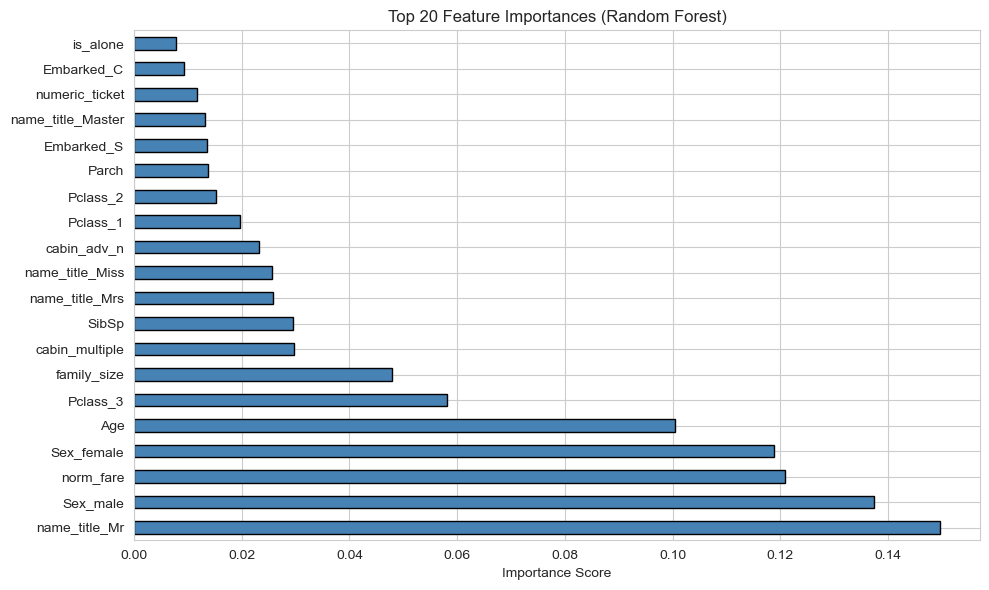

In [103]:
# Feature importance from best Random Forest
best_rf = best_clf_rf.best_estimator_.fit(X_train_scaled, y_train)
feat_importances = pd.Series(best_rf.feature_importances_, index=X_train_scaled.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(20).plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Top 20 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [104]:
# 5. XGBoost
xgb = XGBClassifier(random_state=1, verbosity=0)
param_grid = {
    'n_estimators': [450, 500, 550],
    'colsample_bytree': [0.75, 0.8, 0.85],
    'max_depth': [None],
    'reg_alpha': [1],
    'reg_lambda': [2, 5, 10],
    'subsample': [0.55, 0.6, 0.65],
    'learning_rate': [0.5],
    'gamma': [0.5, 1, 2],
    'min_child_weight': [0.01]
}
clf_xgb = GridSearchCV(xgb, param_grid=param_grid, cv=5, n_jobs=-1)
best_clf_xgb = clf_xgb.fit(X_train_scaled, y_train)
clf_performance(best_clf_xgb, 'XGBoost')


XGBoost
  Best Score:      0.8504
  Best Parameters: {'colsample_bytree': 0.8, 'gamma': 0.5, 'learning_rate': 0.5, 'max_depth': None, 'min_child_weight': 0.01, 'n_estimators': 500, 'reg_alpha': 1, 'reg_lambda': 10, 'subsample': 0.55}


## 8. Ensemble Voting Classifiers

In [105]:
best_lr  = best_clf_lr.best_estimator_
best_knn = best_clf_knn.best_estimator_
best_svc = best_clf_svc.best_estimator_
best_rf  = best_clf_rf.best_estimator_
best_xgb = best_clf_xgb.best_estimator_
 
voting_clf_hard = VotingClassifier(
    estimators=[('knn', best_knn), ('rf', best_rf), ('svc', best_svc)], voting='hard')
voting_clf_soft = VotingClassifier(
    estimators=[('knn', best_knn), ('rf', best_rf), ('svc', best_svc)], voting='soft')
voting_clf_all = VotingClassifier(
    estimators=[('knn', best_knn), ('rf', best_rf), ('svc', best_svc), ('lr', best_lr)], voting='soft')
voting_clf_xgb = VotingClassifier(
    estimators=[('knn', best_knn), ('rf', best_rf), ('svc', best_svc), ('xgb', best_xgb), ('lr', best_lr)], voting='soft')
 
vc_results = {}
for clf, name in [
    (voting_clf_hard, 'Hard Vote (KNN+RF+SVC)'),
    (voting_clf_soft, 'Soft Vote (KNN+RF+SVC)'),
    (voting_clf_all,  'Soft Vote (KNN+RF+SVC+LR)'),
    (voting_clf_xgb,  'Soft Vote (All incl. XGB)'),
]:
    scores = cross_val_score(clf, X_train_scaled, y_train, cv=5)
    vc_results[name] = scores.mean()
    print(f"{name:35s} | Mean: {scores.mean():.4f} | Std: {scores.std():.4f}")

Hard Vote (KNN+RF+SVC)              | Mean: 0.8302 | Std: 0.0245
Soft Vote (KNN+RF+SVC)              | Mean: 0.8234 | Std: 0.0274
Soft Vote (KNN+RF+SVC+LR)           | Mean: 0.8279 | Std: 0.0235
Soft Vote (All incl. XGB)           | Mean: 0.8324 | Std: 0.0221


## 9. Final Model Summary Table

In [106]:
tuned_results = {
    'Naive Bayes':         (baseline_results['Naive Bayes'], None),
    'Logistic Regression': (baseline_results['Logistic Regression'], best_clf_lr.best_score_),
    'Decision Tree':       (baseline_results['Decision Tree'], None),
    'KNN':                 (baseline_results['KNN'], best_clf_knn.best_score_),
    'Random Forest':       (baseline_results['Random Forest'], best_clf_rf.best_score_),
    'SVC':                 (baseline_results['SVC'], best_clf_svc.best_score_),
    'XGBoost':             (baseline_results['XGBoost'], best_clf_xgb.best_score_),
}
 
summary_df = pd.DataFrame([
    {'Model': k, 'Baseline CV Acc': f"{v[0]:.3f}", 'Tuned CV Acc': f"{v[1]:.3f}" if v[1] else 'N/A'}
    for k, v in tuned_results.items()
])
print("\n===== Model Performance Summary =====")
print(summary_df.to_string(index=False))


===== Model Performance Summary =====
              Model Baseline CV Acc Tuned CV Acc
        Naive Bayes           0.724          N/A
Logistic Regression           0.818        0.826
      Decision Tree           0.780          N/A
                KNN           0.805        0.826
      Random Forest           0.807        0.834
                SVC           0.831        0.832
            XGBoost           0.819        0.850


## Predictions & Submission Files

In [107]:
# Fit all ensembles
for clf in [voting_clf_hard, voting_clf_soft, voting_clf_all, voting_clf_xgb]:
    clf.fit(X_train_scaled, y_train)
best_rf.fit(X_train_scaled, y_train)
 
# Predict
y_hat_vc_hard = voting_clf_hard.predict(X_test_scaled).astype(int)
y_hat_vc_soft = voting_clf_soft.predict(X_test_scaled).astype(int)
y_hat_vc_all  = voting_clf_all.predict(X_test_scaled).astype(int)
y_hat_vc_xgb  = voting_clf_xgb.predict(X_test_scaled).astype(int)
y_hat_rf      = best_rf.predict(X_test_scaled).astype(int)
y_hat_xgb     = best_clf_xgb.best_estimator_.predict(X_test_scaled).astype(int)
 
# Save submissions
submissions = {
    'submission_rf.csv':       y_hat_rf,
    'submission_vc_hard.csv':  y_hat_vc_hard,
    'submission_vc_soft.csv':  y_hat_vc_soft,
    'submission_vc_all.csv':   y_hat_vc_all,
    'submission_vc_xgb.csv':   y_hat_vc_xgb,
    'xgb_submission.csv':      y_hat_xgb,
}
for fname, preds in submissions.items():
    pd.DataFrame({'PassengerId': test.PassengerId, 'Survived': preds}).to_csv(fname, index=False)
    print(f"Saved: {fname}")
 
print("\nAll submissions saved successfully.")

Saved: submission_rf.csv
Saved: submission_vc_hard.csv
Saved: submission_vc_soft.csv
Saved: submission_vc_all.csv
Saved: submission_vc_xgb.csv
Saved: xgb_submission.csv

All submissions saved successfully.
